In [51]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import END, START, StateGraph
from dotenv import load_dotenv


load_dotenv()

True

In [ ]:
llm = ChatGroq(model="gemma2-9b-it")

In [53]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]

In [54]:
def chat_node(state: ChatState):
    # Take user query from state
    messages = state['messages']

    # send this to llm 
    response = llm.invoke(messages)
    
    # repsonse store state
    return{'messages' : [response]}

In [55]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edeges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

# compile the graph

chatbot = graph.compile()


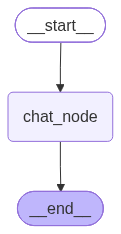

In [56]:
chatbot

In [58]:
initial_state = {
    "messages" : [HumanMessage(content="what is object oriented progeamming?")]
}
response = chatbot.invoke(initial_state)
response

NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8b-instant` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

api_key = os.getenv("GROQ_API_KEY")
print(f"Key detected: {api_key is not None}")
if api_key:
    # Print the prefix and length to avoid leaking full secret
    print(f"Starts with 'gsk_': {api_key.startswith('gsk_')}")
    print(f"Key length: {len(api_key.strip())}")

Key detected: True
Starts with 'gsk_': True
Key length: 56
